# Part 1 — Setup, Data Loading & EDA

# Task 2: Customer Segmentation — Mall Customers
K-Means clustering on Annual Income vs Spending Score | Best model: **K=5, Silhouette=0.5547**

## 1. Setup & Data Loading

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
df = pd.read_csv(os.path.join(path, "Mall_Customers.csv"))
df.columns = ['CustomerID', 'Gender', 'Age', 'Income', 'Spending']

print("Shape:", df.shape)
print(df.describe())
print("Missing values:", df.isnull().sum().sum())

100%|██████████| 1.55k/1.55k [00:00<00:00, 561kB/s]

Extracting files...
Shape: (200, 5)
       CustomerID         Age      Income    Spending
count  200.000000  200.000000  200.000000  200.000000
mean   100.500000   38.850000   60.560000   50.200000
std     57.879185   13.969007   26.264721   25.823522
min      1.000000   18.000000   15.000000    1.000000
25%     50.750000   28.750000   41.500000   34.750000
50%    100.500000   36.000000   61.500000   50.000000
75%    150.250000   49.000000   78.000000   73.000000
max    200.000000   70.000000  137.000000   99.000000
Missing values: 0


## 2. Exploratory Data Analysis

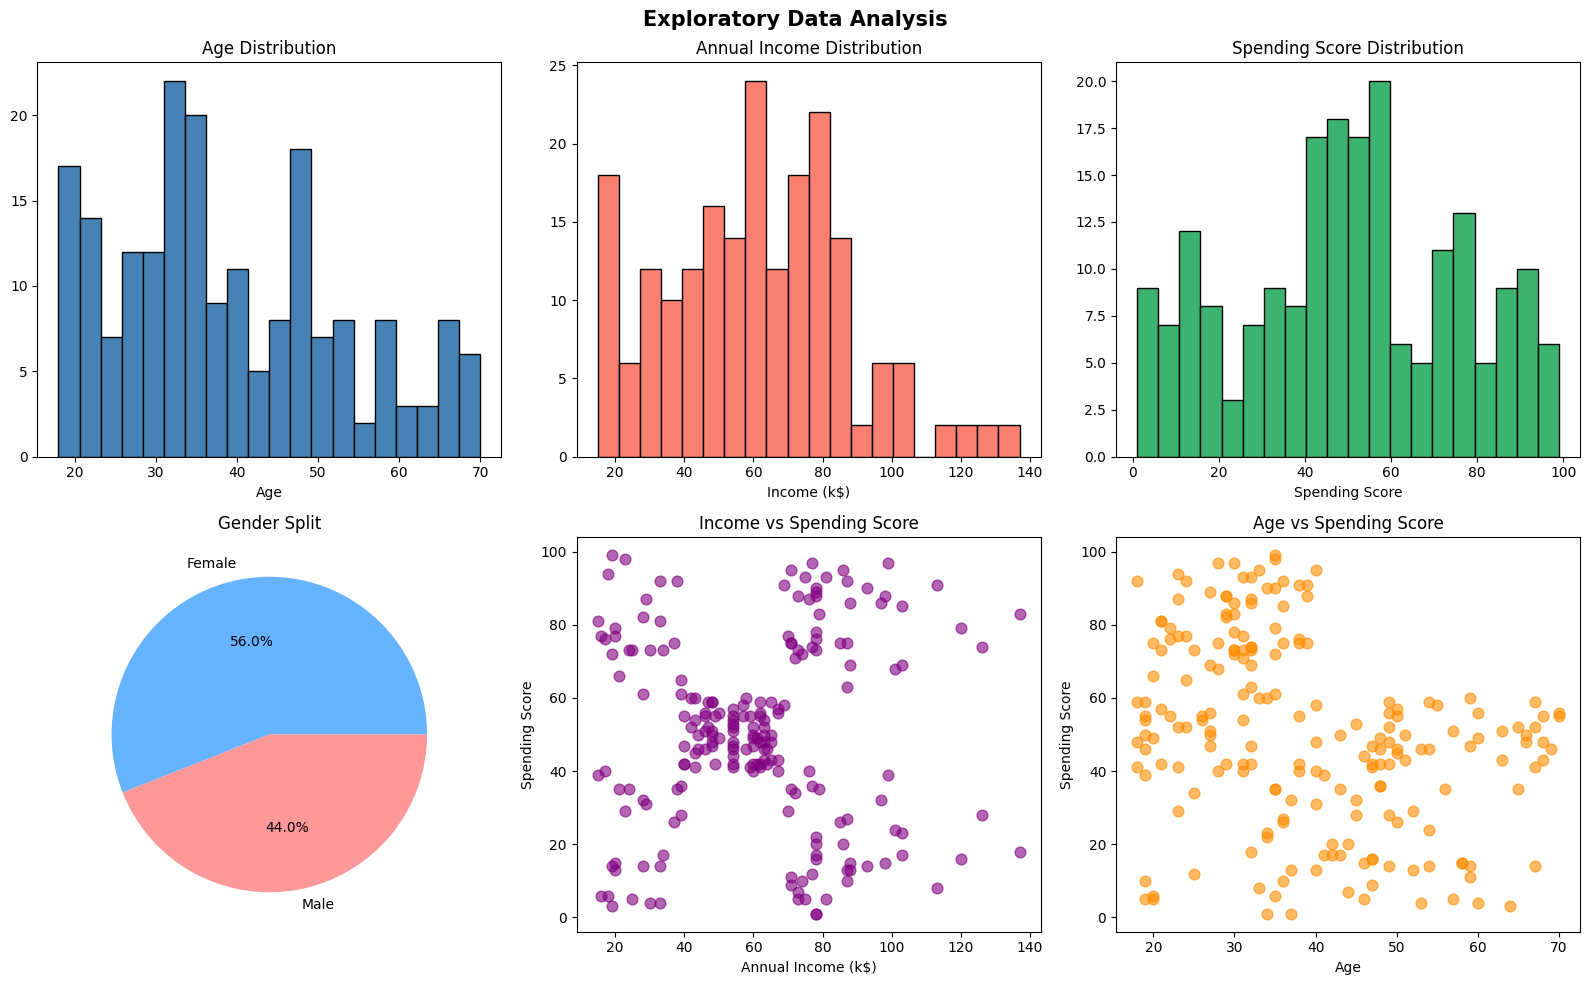

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')

axes[0,1].hist(df['Income'], bins=20, color='salmon', edgecolor='black')
axes[0,1].set_title('Annual Income Distribution')
axes[0,1].set_xlabel('Income (k$)')

axes[0,2].hist(df['Spending'], bins=20, color='mediumseagreen', edgecolor='black')
axes[0,2].set_title('Spending Score Distribution')
axes[0,2].set_xlabel('Spending Score')

df['Gender'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%',
                                  colors=['#66b3ff','#ff9999'])
axes[1,0].set_title('Gender Split')
axes[1,0].set_ylabel('')

axes[1,1].scatter(df['Income'], df['Spending'], c='purple', alpha=0.6, s=60)
axes[1,1].set_title('Income vs Spending Score')
axes[1,1].set_xlabel('Annual Income (k$)')
axes[1,1].set_ylabel('Spending Score')

axes[1,2].scatter(df['Age'], df['Spending'], c='darkorange', alpha=0.6, s=60)
axes[1,2].set_title('Age vs Spending Score')
axes[1,2].set_xlabel('Age')
axes[1,2].set_ylabel('Spending Score')

plt.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

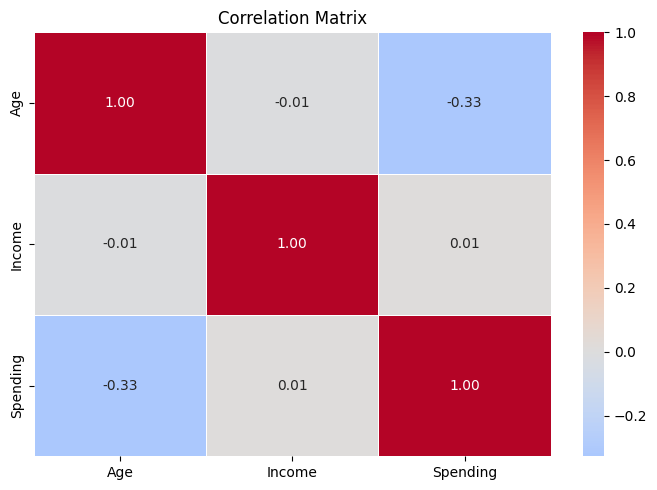

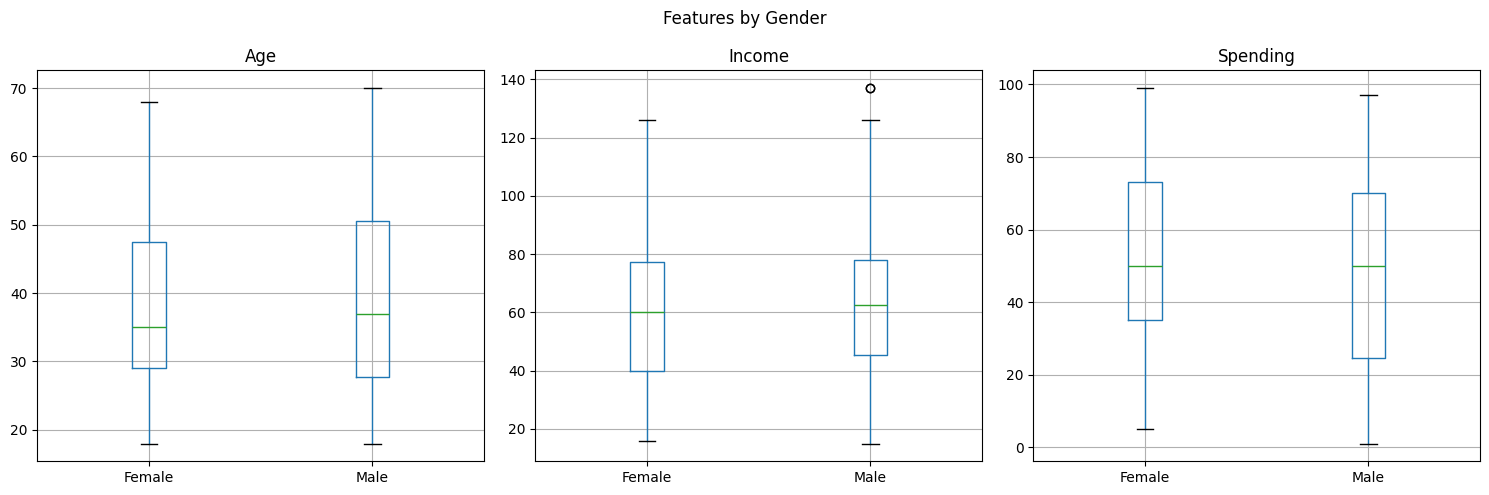

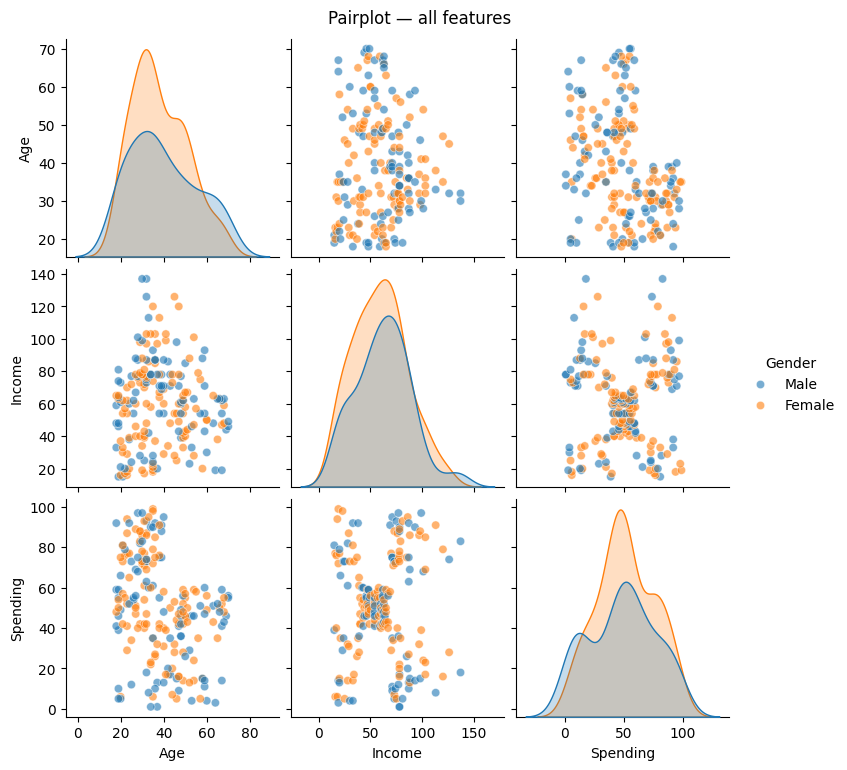

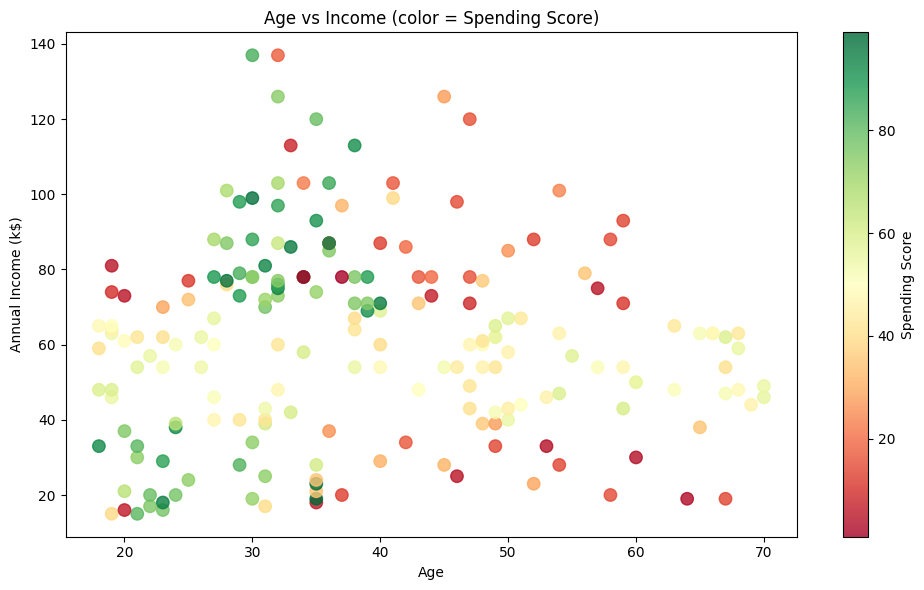

In [3]:
# Correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(df[['Age','Income','Spending']].corr(), annot=True,
            fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Boxplots by gender
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Age', 'Income', 'Spending']):
    df.boxplot(column=col, by='Gender', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Features by Gender')
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df[['Age','Income','Spending','Gender']], hue='Gender',
             diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot — all features', y=1.02)
plt.show()

# Age vs Income colored by spending
plt.figure(figsize=(10, 6))
sc = plt.scatter(df['Age'], df['Income'], c=df['Spending'],
                 cmap='RdYlGn', s=80, alpha=0.8)
plt.colorbar(sc, label='Spending Score')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Age vs Income (color = Spending Score)')
plt.tight_layout()
plt.show()